# SVM Demand Prediction — 1-Hour Time Windows

This notebook applies the same per-area SVM pipeline developed in `03.02_prediction_svm_improved.ipynb`
to **1-hour time windows** instead of 4-hour windows.

## Why 1-hour granularity?

From a fleet management perspective, 1-hour predictions are significantly more actionable than
4-hour predictions: a taxi operator can reposition vehicles within the hour based on expected
demand. The coarser 4-hour window averages over rush-hour peaks and off-peak troughs, hiding
sub-window patterns that a 1-hour model can capture.

## What changes — key differences from 03.02

| Aspect | 4-hour (03.02) | 1-hour (this notebook) |
|---|---|---|
| Rows per area | ~1,750 | ~7,000 (4×) |
| Median demand (CA 8) | ~595 trips | ~149 trips |
| Zero-count windows | Rare for included areas | More common, especially overnight |
| Weather aggregation | Average over 4h | Native hourly resolution — no averaging needed |
| Cyclic hour feature | 6 distinct values (0,4,8,…,20) | 24 distinct values (0–23) — finer resolution |
| RBF SVR scalability | Fast (~2min for all areas) | Slow (~15–30min for all areas) |
| **Primary model** | **RBF SVR** | **LinearSVR** (RBF available but slow) |

## Constraints and considerations

### 1. SVR scalability at 7,000 rows per area

Standard SVR with the RBF kernel uses libsvm which scales as **O(n²)–O(n³)**. At ~5,600
training rows per high-demand area (80% of 7,000), one SVR fit takes roughly 10–60 seconds.
For 26+ included areas without GridSearch that is already 5–25 minutes. GridSearch on top
would multiply this by 18 (3 folds × 6 combinations), resulting in 90 minutes or more — not
feasible on a laptop.

**Decision:** `LinearSVR` is the primary model at 1-hour granularity. It uses a liblinear
solver that scales as O(n), making the same 26-area run take seconds. The RBF SVR code is
kept as an optional cell with a runtime warning.

### 2. Lower counts and more zero-count windows

At 1-hour resolution, even included areas will have near-zero demand in overnight windows
(approximately 00:00–05:00). This is not missing data — it is genuine absence of demand.
The `log1p` transform handles zeros correctly (`log1p(0) = 0`), so no special treatment is
needed. However, be aware that the model sees many (hour=2, temperature=−5, is_weekend=0) →
count=0 rows, which anchors the night-time predictions well.

### 3. Threshold re-derivation required

The threshold of median ≥ 10 trips from 03.02 was calibrated for 4-hour windows.
At 1-hour granularity, the same areas will have roughly 4× lower medians. A direct
conversion suggests median ≥ 3 as a starting point, but the actual threshold must be
re-derived empirically from the 1-hour distribution — the bar chart in Section 2 shows
the natural break in the data.

### 4. Weather is now at native resolution

The 4-hour pipeline averaged weather measurements over four hourly readings. At 1-hour
resolution the weather data is already aligned with the taxi aggregation — each row joins
directly to one hourly weather observation. This means weather features are **more precise**
at 1-hour granularity.

### 5. The hour cyclic feature is more informative

In the 4-hour pipeline, `hour` could only take values {0, 4, 8, 12, 16, 20} — just 6
distinct points on the sine/cosine cycle. At 1-hour, all 24 values are present, giving the
model a much finer signal to distinguish morning rush (08:00) from a general "early morning"
bucket.


In [32]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from sklearn.svm import SVR, LinearSVR
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import contextily as ctx

TAXI_DATA_PATH       = "../data/chicago_taxi_2025_clean.parquet"
WEATHER_DATA_PATH    = "../data/chicago_weather_2025_hourly.csv"
COMMUNITY_AREAS_PATH = "../data/community_areas_chicago.geojson"


## 1. Data Loading & Feature Engineering (1-Hour Resolution)

The pipeline is simplified compared to 03.02: the 4-hour aggregation step is replaced by
a direct 1-hour groupby. Weather features join at native hourly resolution — no averaging.


In [33]:
taxi_data    = pd.read_parquet(TAXI_DATA_PATH)
weather_data = pd.read_csv(WEATHER_DATA_PATH)

# Aggregate taxi trips to 1-hour windows
taxi_data['timestamp_1h'] = pd.to_datetime(taxi_data['trip_start_timestamp']).dt.floor('h')
df_all = (
    taxi_data
    .groupby(['pickup_community_area', 'timestamp_1h'])
    .size()
    .reset_index(name='count')
    .rename(columns={'pickup_community_area': 'community_area',
                     'timestamp_1h': 'timestamp'})
)

# Join weather at native hourly resolution (no averaging needed)
weather_data['datetime'] = pd.to_datetime(weather_data['datetime'])
df_all = df_all.join(
    weather_data.set_index('datetime'), on='timestamp', how='left'
)

# Drop non-usable weather columns (same reasoning as 03.02)
df_all.drop(
    columns=[c for c in ['weather_description', 'weather_code', 'apparent_temperature']
             if c in df_all.columns],
    inplace=True
)

print(f"Rows: {len(df_all):,}   Areas: {df_all['community_area'].nunique()}")
print(f"Average rows per area: {len(df_all) / df_all['community_area'].nunique():.0f}")
df_all.head(3)


Rows: 386,163   Areas: 77
Average rows per area: 5015


,community_area,timestamp,count,temperature_2m,precipitation,snowfall,wind_speed_10m,cloud_cover
0,1,2025-01-01 00:00:00,2,0.7,0.0,0.0,8.6,100
1,1,2025-01-01 01:00:00,5,0.8,0.0,0.0,8.1,100
2,1,2025-01-01 02:00:00,4,0.6,0.0,0.0,8.8,100


In [34]:
# Cyclic time features — now all 24 hour values are present (vs only 6 at 4h granularity)
df_all['hour']        = df_all['timestamp'].dt.hour
df_all['day_of_week'] = df_all['timestamp'].dt.dayofweek
df_all['month']       = df_all['timestamp'].dt.month

df_all['hour_sin']        = np.sin(2 * np.pi * df_all['hour'] / 24)
df_all['hour_cos']        = np.cos(2 * np.pi * df_all['hour'] / 24)
df_all['day_of_week_sin'] = np.sin(2 * np.pi * df_all['day_of_week'] / 7)
df_all['day_of_week_cos'] = np.cos(2 * np.pi * df_all['day_of_week'] / 7)
df_all['month_sin']       = np.sin(2 * np.pi * df_all['month'] / 12)
df_all['month_cos']       = np.cos(2 * np.pi * df_all['month'] / 12)

df_all['is_weekend'] = (df_all['timestamp'].dt.dayofweek >= 5).astype(int)

us_holidays_2025 = pd.to_datetime([
    '2025-01-01', '2025-01-20', '2025-02-17', '2025-05-26',
    '2025-06-19', '2025-07-04', '2025-09-01', '2025-10-13',
    '2025-11-11', '2025-11-27', '2025-12-25'
])
df_all['is_holiday'] = df_all['timestamp'].dt.date.isin(us_holidays_2025.date).astype(int)

df_all.drop(columns=['hour', 'day_of_week', 'month'], inplace=True)

print(f"Zero-count windows: {(df_all['count'] == 0).sum():,} "
      f"({(df_all['count'] == 0).mean()*100:.1f}% of all rows)")
print(f"Median count across all rows: {df_all['count'].median():.1f}")
print(f"Mean count across all rows:   {df_all['count'].mean():.1f}")


Zero-count windows: 0 (0.0% of all rows)
Median count across all rows: 2.0
Mean count across all rows:   15.8


## 2. Demand Analysis at 1-Hour Granularity

At 1-hour resolution the demand distribution shifts significantly compared to 03.02.
The per-area median will be roughly 4× lower. We re-derive the threshold empirically
from the data rather than importing the value from 03.02.


In [35]:
area_stats = (
    df_all.groupby('community_area')['count']
    .agg(median='median', mean='mean', max='max', std='std', n_rows='count')
    .reset_index()
    .sort_values('median', ascending=False)
)
area_stats[['median','mean','std']] = area_stats[['median','mean','std']].round(2)

print("Demand distribution across all 77 areas (1-hour windows):")
print(f"  Highest median: {area_stats['median'].max():.1f} trips/h")
print(f"  Lowest median:  {area_stats['median'].min():.1f} trips/h")
print(f"  Median of medians: {area_stats['median'].median():.1f}")
print()
for thresh in [2, 3, 4, 5]:
    n = (area_stats['median'] >= thresh).sum()
    print(f"  Areas with median >= {thresh}: {n}")


Demand distribution across all 77 areas (1-hour windows):
  Highest median: 159.0 trips/h
  Lowest median:  1.0 trips/h
  Median of medians: 2.0

  Areas with median >= 2: 42
  Areas with median >= 3: 22
  Areas with median >= 4: 19
  Areas with median >= 5: 15


### 2.1 Sorted Median Demand — Choosing the 1-Hour Threshold

The equivalent of the 4-hour threshold (≥ 10 trips/window) at 1-hour resolution is
approximately **≥ 3 trips/hour** (10 ÷ 4 = 2.5, rounded up). The bar chart confirms
whether there is a natural break in the distribution around this value.

Note that the zero-count percentage printed above reflects that even included areas have
overnight hours with no activity — this is expected and handled correctly by `log1p`.


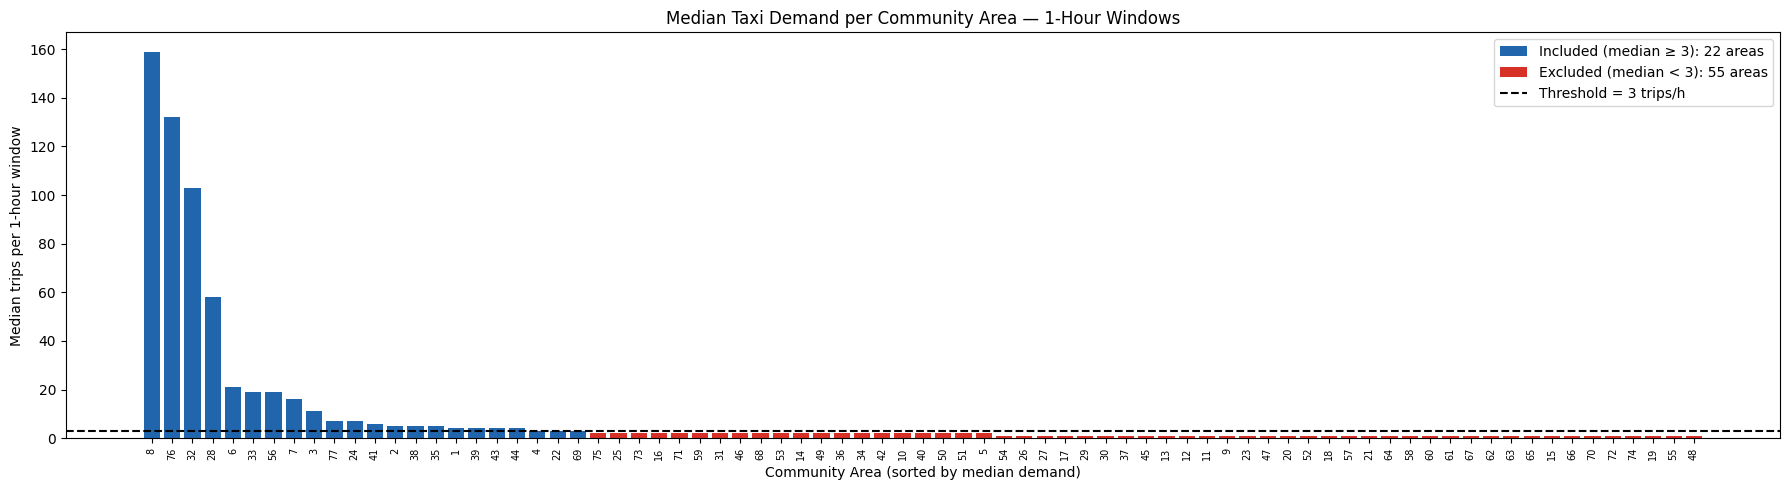

In [36]:
DEMAND_THRESHOLD_1H = 3

sorted_stats = area_stats.sort_values('median', ascending=False)
colors = ['#2166ac' if m >= DEMAND_THRESHOLD_1H else '#d73027' for m in sorted_stats['median']]

fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(range(len(sorted_stats)), sorted_stats['median'], color=colors, width=0.8)
ax.axhline(y=DEMAND_THRESHOLD_1H, color='black', linestyle='--', linewidth=1.5)
ax.set_xticks(range(len(sorted_stats)))
ax.set_xticklabels(sorted_stats['community_area'].astype(str), rotation=90, fontsize=7)
ax.set_xlabel('Community Area (sorted by median demand)')
ax.set_ylabel('Median trips per 1-hour window')
ax.set_title('Median Taxi Demand per Community Area — 1-Hour Windows')

n_inc = (sorted_stats['median'] >= DEMAND_THRESHOLD_1H).sum()
n_exc = (sorted_stats['median'] <  DEMAND_THRESHOLD_1H).sum()
ax.legend(handles=[
    Patch(facecolor='#2166ac', label=f'Included (median ≥ {DEMAND_THRESHOLD_1H}): {n_inc} areas'),
    Patch(facecolor='#d73027', label=f'Excluded (median < {DEMAND_THRESHOLD_1H}): {n_exc} areas'),
    plt.Line2D([0],[0], color='black', linestyle='--', label=f'Threshold = {DEMAND_THRESHOLD_1H} trips/h'),
])
plt.tight_layout()
plt.show()


In [37]:
included_areas = sorted(area_stats[area_stats['median'] >= DEMAND_THRESHOLD_1H]['community_area'].tolist())
excluded_areas = sorted(area_stats[area_stats['median'] <  DEMAND_THRESHOLD_1H]['community_area'].tolist())

print(f"Areas included (median >= {DEMAND_THRESHOLD_1H}): {len(included_areas)}")
print(f"Areas excluded (median <  {DEMAND_THRESHOLD_1H}): {len(excluded_areas)}")

included_stats = area_stats[area_stats['median'] >= DEMAND_THRESHOLD_1H].sort_values('median', ascending=False)
print("\nIncluded areas:")
print(included_stats[['community_area','median','mean','max','n_rows']].to_string(index=False))


Areas included (median >= 3): 22
Areas excluded (median <  3): 55

Included areas:
 community_area  median   mean  max  n_rows
              8   159.0 162.54  530    8759
             76   132.0 141.07  488    8714
             32   103.0 117.01  478    8708
             28    58.0  74.14  449    8601
              6    21.0  25.20  140    8626
             33    19.0  26.48  219    8283
             56    19.0  19.93   76    7999
              7    16.0  17.40   98    8217
              3    11.0  13.30   61    8108
             77     7.0   8.90   39    8042
             24     7.0   8.37   55    8085
             41     6.0   7.35   44    6711
              2     5.0   5.27   21    7830
             38     5.0   5.30   20    6935
             35     5.0   6.16   29    7202
             43     4.0   5.03   22    7392
             44     4.0   4.35   21    7629
              1     4.0   4.31   20    7715
             39     4.0   4.22   18    6725
              4     3.0   3.23   22  

## 3. Feature Set

Identical to 03.02 minus `is_holiday` (removed after feature importance analysis showed
near-zero contribution). The 12 features are:

| Group | Features |
|---|---|
| Time (cyclic) | `hour_sin/cos`, `day_of_week_sin/cos`, `month_sin/cos` |
| Weather | `temperature_2m`, `precipitation`, `snowfall`, `wind_speed_10m`, `cloud_cover` |
| Binary | `is_weekend`, `is_holiday` |

At 1-hour resolution the cyclic hour features are particularly important: the model now sees
all 24 distinct hour values, giving it fine-grained control over intra-day patterns.


In [38]:
FEATURE_COLS = [
    'temperature_2m', 'precipitation', 'snowfall', 'wind_speed_10m', 'cloud_cover',
    'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos',
    'month_sin', 'month_cos', 'is_weekend', 'is_holiday'
]


## 4. Per-Area LinearSVR — Primary Model at 1-Hour Granularity

LinearSVR is the primary model at this granularity for the scalability reason explained in
the introduction: ~5,600 training rows per high-demand area make RBF SVR impractically slow
for a per-area loop across 26+ areas. LinearSVR with a liblinear solver handles this trivially.

The pipeline is otherwise identical to 03.02:
- `log1p` target transform, back-transformed with `expm1` for metrics
- `StandardScaler` on all features
- 80/20 random train/test split with `random_state=42`


In [39]:
import time

print(f"Training LinearSVR for {len(included_areas)} areas at 1-hour granularity...\n")
t0 = time.time()

linear_results = []
linear_models  = {}
linear_y_test  = []
linear_y_pred  = []

for area in included_areas:
    df_area = df_all[df_all['community_area'] == area]

    X = df_area[FEATURE_COLS]
    y = np.log1p(df_area['count'])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('svm',    LinearSVR(C=1.0, epsilon=0.1, max_iter=10000, random_state=42))
    ])
    model.fit(X_train, y_train)

    y_pred_area = np.expm1(model.predict(X_test))
    y_test_area = np.expm1(y_test)

    linear_results.append({
        'community_area': int(area),
        'median_demand':  round(df_area['count'].median(), 1),
        'n_train': len(X_train),
        'n_test':  len(X_test),
        'r2':   round(r2_score(y_test_area, y_pred_area), 4),
        'mae':  round(mean_absolute_error(y_test_area, y_pred_area), 2),
        'rmse': round(np.sqrt(mean_squared_error(y_test_area, y_pred_area)), 2),
    })
    linear_models[int(area)] = model
    linear_y_test.extend(y_test_area.values)
    linear_y_pred.extend(y_pred_area)

linear_df    = pd.DataFrame(linear_results)
overall_r2   = r2_score(linear_y_test, linear_y_pred)
overall_mae  = mean_absolute_error(linear_y_test, linear_y_pred)
overall_rmse = np.sqrt(mean_squared_error(linear_y_test, linear_y_pred))

print(f"Done in {time.time()-t0:.1f}s\n")
print(f"LinearSVR 1h — Overall R²   (pooled): {overall_r2:.3f}")
print(f"LinearSVR 1h — Overall MAE  (pooled): {overall_mae:.2f} trips")
print(f"LinearSVR 1h — Overall RMSE (pooled): {overall_rmse:.2f} trips")
print(f"Median R² per area: {linear_df['r2'].median():.3f}")
print(f"Mean R² per area:   {linear_df['r2'].mean():.3f}")
print(f"\nFull results (sorted by R²):")
print(linear_df.sort_values('r2', ascending=False).to_string(index=False))


Training LinearSVR for 22 areas at 1-hour granularity...

Done in 7.9s

LinearSVR 1h — Overall R²   (pooled): 0.768
LinearSVR 1h — Overall MAE  (pooled): 12.63 trips
LinearSVR 1h — Overall RMSE (pooled): 32.09 trips
Median R² per area: 0.445
Mean R² per area:   0.429

Full results (sorted by R²):
 community_area  median_demand  n_train  n_test     r2   mae  rmse
             41            6.0     5368    1343 0.6567  2.30  3.23
             77            7.0     6433    1609 0.6131  2.93  4.08
              8          159.0     7007    1752 0.6028 54.62 75.95
             35            5.0     5761    1441 0.5893  2.01  2.75
             32          103.0     6966    1742 0.5794 44.43 64.92
             38            5.0     5548    1387 0.5687  1.79  2.47
             76          132.0     6971    1743 0.5404 50.20 71.36
             43            4.0     5913    1479 0.5274  1.74  2.30
              2            5.0     6264    1566 0.5210  1.82  2.43
             39            4.0  

## 5. Feature Importance (LinearSVR Coefficients)

Feature importance = `|coefficient|` after StandardScaler, as in 03.02.
At 1-hour granularity we expect the cyclic hour features to be even more dominant
than at 4-hour granularity, since the finer time resolution gives the model a clearer
signal to work with.


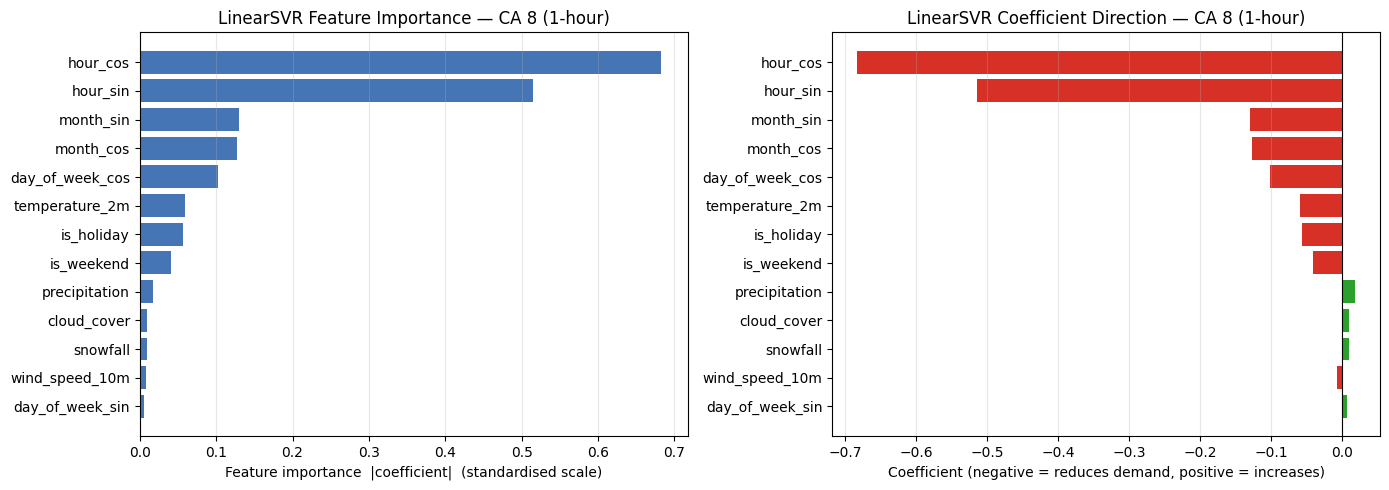

Top 5 most important features:
        feature  importance  coefficient
       hour_cos    0.682921    -0.682921
       hour_sin    0.514179    -0.514179
      month_sin    0.129595    -0.129595
      month_cos    0.126697    -0.126697
day_of_week_cos    0.101958    -0.101958


In [40]:
COEF_AREA = 8
coefs = linear_models[COEF_AREA].named_steps['svm'].coef_

coef_df = pd.DataFrame({
    'feature':     FEATURE_COLS,
    'coefficient': coefs,
    'importance':  np.abs(coefs)
}).sort_values('importance', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(coef_df['feature'], coef_df['importance'], color='#4575b4')
axes[0].set_xlabel('Feature importance  |coefficient|  (standardised scale)')
axes[0].set_title(f'LinearSVR Feature Importance — CA {COEF_AREA} (1-hour)')
axes[0].grid(axis='x', alpha=0.3)

colors_dir = ['#d73027' if c < 0 else '#2ca02c' for c in coef_df['coefficient']]
axes[1].barh(coef_df['feature'], coef_df['coefficient'], color=colors_dir)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Coefficient (negative = reduces demand, positive = increases)')
axes[1].set_title(f'LinearSVR Coefficient Direction — CA {COEF_AREA} (1-hour)')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("Top 5 most important features:")
print(coef_df[['feature','importance','coefficient']].tail(5).iloc[::-1].to_string(index=False))


## 6. RBF SVR — Optional (Runtime Warning)

The code below runs per-area RBF SVR at 1-hour granularity. With ~5,600 training rows
per area and 26+ areas, expect **15–30 minutes** of total runtime on a standard laptop
(vs ~2 minutes at 4-hour granularity). No GridSearch is run here for this reason.

Uncomment the training loop to execute. The results can be directly compared to the
LinearSVR above to quantify the non-linear benefit at this granularity.


In [ ]:
FEATURE_COLS_RBF = FEATURE_COLS  # same feature set

rbf_results = []
rbf_models  = {}
rbf_y_test  = []
rbf_y_pred  = []

for area in included_areas:
    df_area = df_all[df_all['community_area'] == area]
    X = df_area[FEATURE_COLS_RBF]
    y = np.log1p(df_area['count'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('svm',    SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1))
    ])
    model.fit(X_train, y_train)
    y_pred_area = np.expm1(model.predict(X_test))
    y_test_area = np.expm1(y_test)
    rbf_results.append({
        'community_area': int(area),
        'median_demand':  round(df_area['count'].median(), 1),
        'r2':   round(r2_score(y_test_area, y_pred_area), 4),
        'mae':  round(mean_absolute_error(y_test_area, y_pred_area), 2),
        'rmse': round(np.sqrt(mean_squared_error(y_test_area, y_pred_area)), 2),
    })
    rbf_models[int(area)] = model
    rbf_y_test.extend(y_test_area.values)
    rbf_y_pred.extend(y_pred_area)

rbf_df = pd.DataFrame(rbf_results)
# 1print("RBF SVR training is commented out — uncomment the block above to run (~15–30 min).")


RBF SVR 1h — Median R²: 0.550
RBF SVR 1h — Overall R²: 0.936


In [49]:
rbf_overall_r2   = r2_score(rbf_y_test, rbf_y_pred)
rbf_overall_mae  = mean_absolute_error(rbf_y_test, rbf_y_pred)
rbf_overall_rmse = np.sqrt(mean_squared_error(rbf_y_test, rbf_y_pred))

print(f"Done in {time.time()-t0:.1f}s\n")
print(f"RBF SVR 1h — Overall R²   (pooled): {rbf_overall_r2:.3f}")
print(f"RBF SVR 1h — Overall MAE  (pooled): {rbf_overall_mae:.2f} trips")
print(f"RBF SVR 1h — Overall RMSE (pooled): {rbf_overall_rmse:.2f} trips")
print(f"Median R² per area: {rbf_df['r2'].median():.3f}")
print(f"Mean R² per area:   {rbf_df['r2'].mean():.3f}")
print(f"\nFull results (sorted by R²):")
print(rbf_df.sort_values('r2', ascending=False).to_string(index=False))


Done in 6757.0s

RBF SVR 1h — Overall R²   (pooled): 0.936
RBF SVR 1h — Overall MAE  (pooled): 6.99 trips
RBF SVR 1h — Overall RMSE (pooled): 16.82 trips
Median R² per area: 0.550
Mean R² per area:   0.532

Full results (sorted by R²):
 community_area  median_demand     r2   mae  rmse
             32          103.0 0.9143 19.02 29.30
              8          159.0 0.8916 24.92 39.68
             28           58.0 0.8623 13.91 25.47
             76          132.0 0.8376 27.87 42.41
              3           11.0 0.7042  3.89  5.80
             77            7.0 0.6885  2.61  3.66
              6           21.0 0.6541  7.16 11.88
             41            6.0 0.6463  2.26  3.28
             33           19.0 0.6455  8.88 16.97
              7           16.0 0.6358  4.99  7.96
             56           19.0 0.5889  6.22  8.63
             35            5.0 0.5104  2.13  3.00
             38            5.0 0.4573  1.93  2.77
              2            5.0 0.4055  1.95  2.71
              

## 7. Results & Evaluation


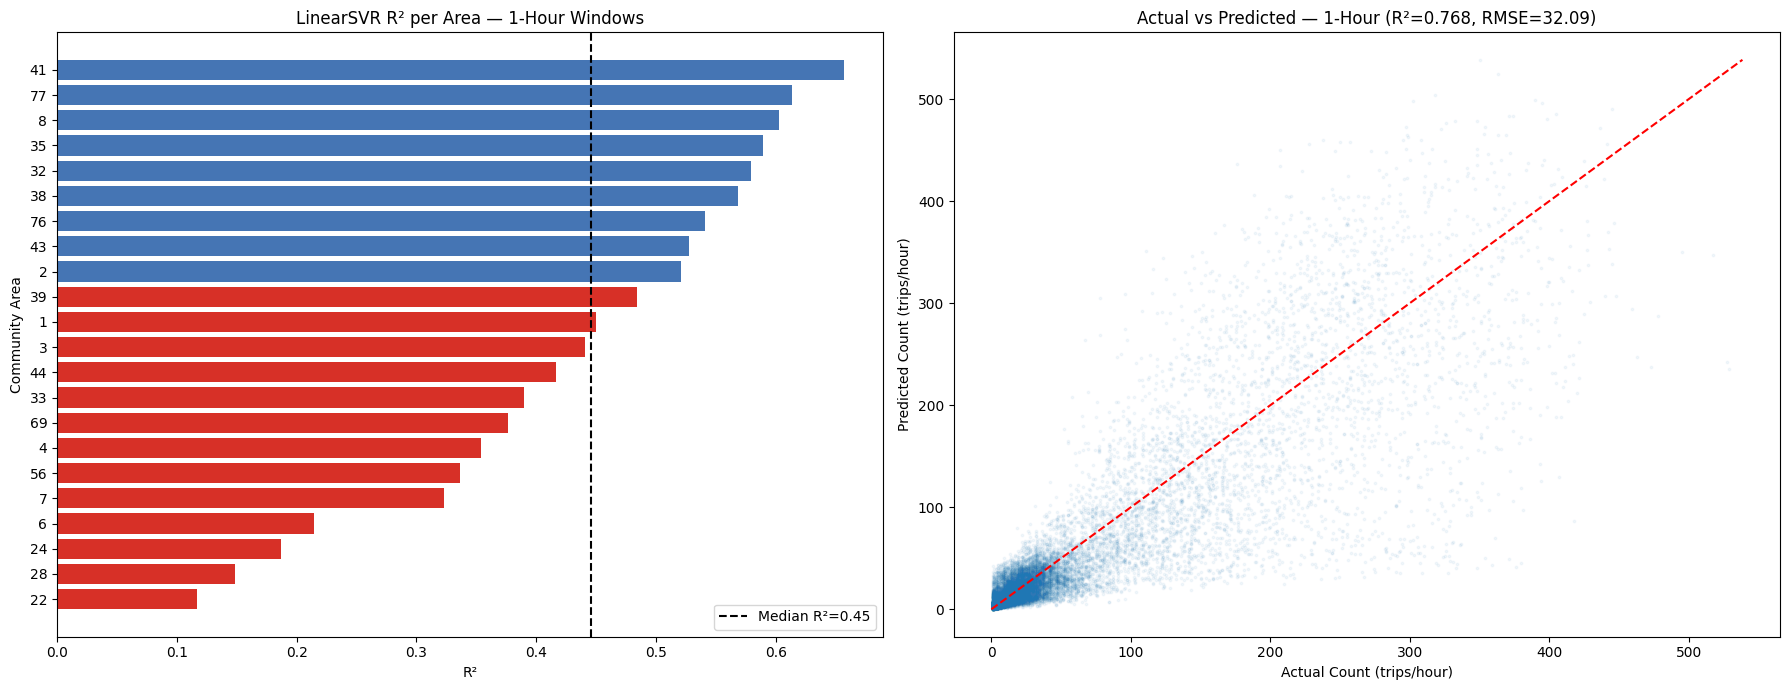

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

results_sorted = linear_df.sort_values('r2')
bar_colors = ['#d73027' if r < 0.5 else '#4575b4' for r in results_sorted['r2']]
axes[0].barh(results_sorted['community_area'].astype(str), results_sorted['r2'], color=bar_colors)
axes[0].axvline(linear_df['r2'].median(), color='black', linestyle='--', linewidth=1.5,
                label=f"Median R²={linear_df['r2'].median():.2f}")
axes[0].set_xlabel('R²')
axes[0].set_ylabel('Community Area')
axes[0].set_title('LinearSVR R² per Area — 1-Hour Windows')
axes[0].legend()

axes[1].scatter(linear_y_test, linear_y_pred, alpha=0.05, s=3)
max_val = max(max(linear_y_test), max(linear_y_pred))
axes[1].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5)
axes[1].set_xlabel('Actual Count (trips/hour)')
axes[1].set_ylabel('Predicted Count (trips/hour)')
axes[1].set_title(f'Actual vs Predicted — 1-Hour (R²={overall_r2:.3f}, RMSE={overall_rmse:.2f})')

plt.tight_layout()
plt.show()


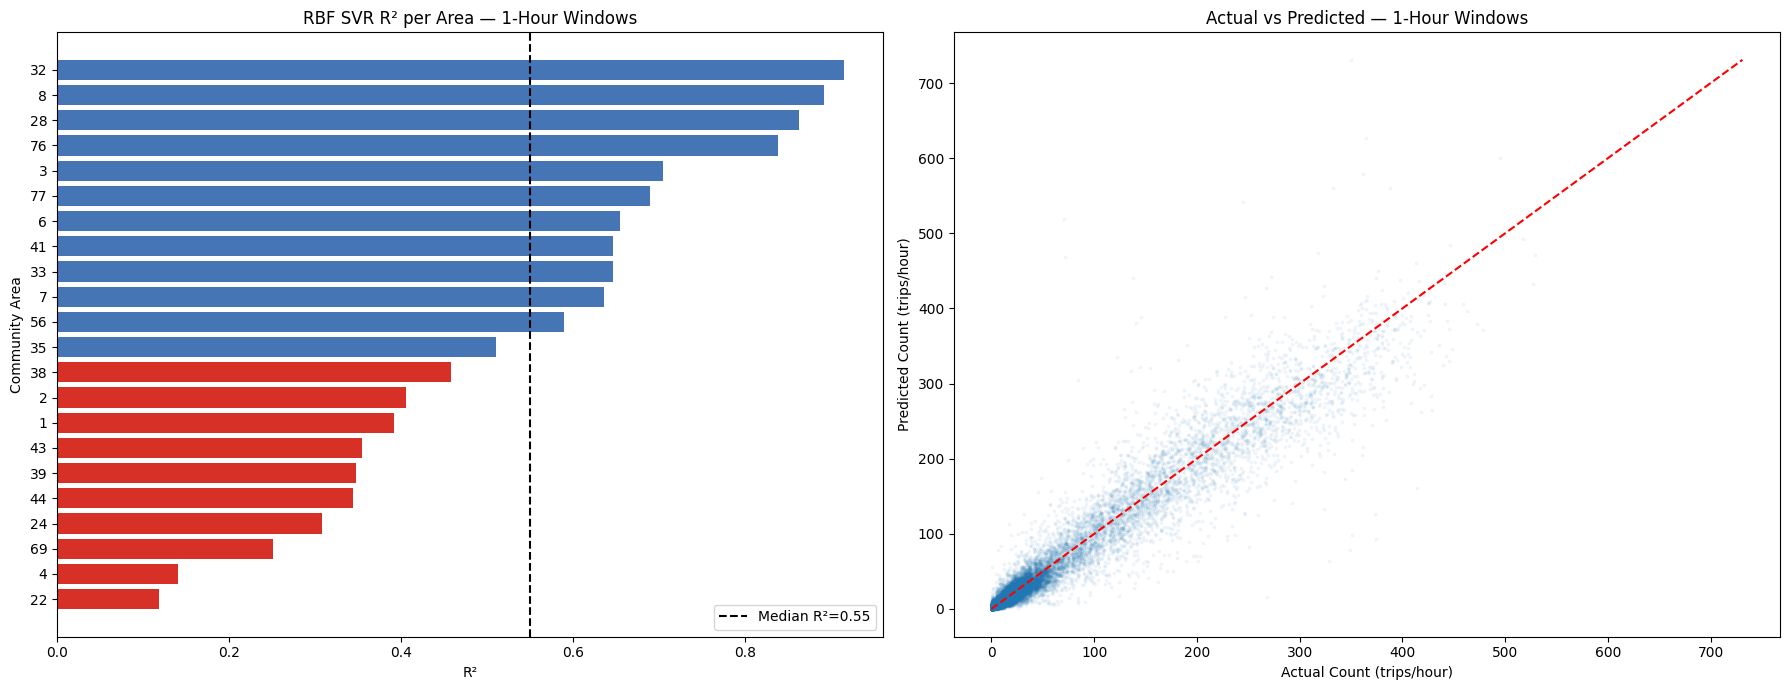

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

results_sorted = rbf_df.sort_values('r2')
bar_colors = ['#d73027' if r < 0.5 else '#4575b4' for r in results_sorted['r2']]
axes[0].barh(results_sorted['community_area'].astype(str), results_sorted['r2'], color=bar_colors)
axes[0].axvline(rbf_df['r2'].median(), color='black', linestyle='--', linewidth=1.5,
                label=f"Median R²={rbf_df['r2'].median():.2f}")
axes[0].set_xlabel('R²')
axes[0].set_ylabel('Community Area')
axes[0].set_title('RBF SVR R² per Area — 1-Hour Windows')
axes[0].legend()

axes[1].scatter(rbf_y_test, rbf_y_pred, alpha=0.05, s=3)
max_val = max(max(rbf_y_test), max(rbf_y_pred))
axes[1].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5)
axes[1].set_xlabel('Actual Count (trips/hour)')
axes[1].set_ylabel('Predicted Count (trips/hour)')
axes[1].set_title(f'Actual vs Predicted — 1-Hour Windows')

plt.tight_layout()
plt.show()


## 8. Comparison with 4-Hour Results

To compare fairly, only the LinearSVR results from 03.02 are used (same model class).
The 4-hour results are hardcoded from the 03.02 run — re-run 03.02 first if you have
updated those values.

**Important caveat on interpretation:** Lower R² at 1-hour does not necessarily mean
the 1-hour model is worse in an absolute sense. At 1-hour, the target variance is smaller
(the counts are lower), so even a well-fitted model will have a lower R² than one trained
on aggregated counts. MAE in original trip units is the more meaningful comparison.


In [43]:
# Paste the LinearSVR median R², overall R², and median MAE from the 03.02 run here
linear_4h_median_r2  = None  # e.g. 0.412 — update from 03.02 output
linear_4h_overall_r2 = None  # e.g. 0.870
linear_4h_median_mae = None  # e.g. 18.5

summary = pd.DataFrame({
    'Granularity':      ['1-hour (this notebook)', '4-hour (03.02)'],
    'Overall R²':       [round(overall_r2, 3),  linear_4h_overall_r2],
    'Median R²/area':   [round(linear_df['r2'].median(), 3), linear_4h_median_r2],
    'Median MAE/area':  [round(linear_df['mae'].median(), 2), linear_4h_median_mae],
    'Median RMSE/area': [round(linear_df['rmse'].median(), 2), None],
})
print("Cross-granularity comparison — LinearSVR:")
print(summary.to_string(index=False))
print()
print("Fill in the 4-hour values from 03.02 to complete the comparison.")


Cross-granularity comparison — LinearSVR:
           Granularity  Overall R²  Median R²/area  Median MAE/area  Median RMSE/area
1-hour (this notebook)       0.768           0.445             2.62              3.66
        4-hour (03.02)         NaN             NaN              NaN               NaN

Fill in the 4-hour values from 03.02 to complete the comparison.


## 9. Excluded Areas — Historical Mean Baseline

As in 03.02, areas below the demand threshold are handled with a simple historical
mean baseline. At 1-hour resolution these areas have median demand < 3 trips/hour —
genuinely no temporal signal to model.


In [44]:
mean_baseline_results = []

for area in excluded_areas:
    df_area = df_all[df_all['community_area'] == area]
    y = df_area['count'].values

    n_train = int(len(y) * 0.8)
    y_train, y_test = y[:n_train], y[n_train:]

    train_mean = y_train.mean()
    y_pred_const = np.full_like(y_test, fill_value=train_mean, dtype=float)

    mean_baseline_results.append({
        'community_area': int(area),
        'median_demand':  round(df_area['count'].median(), 1),
        'train_mean':     round(train_mean, 2),
        'r2':   round(r2_score(y_test, y_pred_const), 4),
        'mae':  round(mean_absolute_error(y_test, y_pred_const), 2),
        'rmse': round(np.sqrt(mean_squared_error(y_test, y_pred_const)), 2),
    })

mean_df = pd.DataFrame(mean_baseline_results)
print(f"Mean baseline — {len(excluded_areas)} excluded areas:")
print(mean_df.sort_values('median_demand', ascending=False).to_string(index=False))
print(f"\nMedian MAE:  {mean_df['mae'].median():.2f} trips/hour")
print(f"Median RMSE: {mean_df['rmse'].median():.2f} trips/hour")


Mean baseline — 55 excluded areas:
 community_area  median_demand  train_mean      r2  mae  rmse
              5            2.0        2.51 -0.0016 1.35  1.72
             25            2.0        2.28 -0.1742 1.01  1.19
             73            2.0        2.03 -0.1594 0.81  0.99
             71            2.0        2.34 -0.3383 0.99  1.12
             68            2.0        2.69 -0.5087 1.24  1.39
             59            2.0        2.39 -0.0002 1.45  1.77
             53            2.0        3.18 -0.7825 1.46  1.65
             51            2.0        2.05 -0.2573 0.81  0.98
             50            2.0        2.07 -0.3750 0.85  1.00
             49            2.0        2.95 -0.2342 1.29  1.53
             42            2.0        2.99 -0.0493 1.41  1.71
             40            2.0        1.93 -0.0722 0.81  0.99
             36            2.0        2.57 -0.2393 1.19  1.35
             34            2.0        2.74 -0.0271 1.35  1.64
             31            2.0     